In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/students-mental-health-assessments/students_mental_health_survey.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=[15,6]

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
df=pd.read_csv('/kaggle/input/students-mental-health-assessments/students_mental_health_survey.csv')
df.head()

,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type
0,25,Others,Male,3.56,3,3,2,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,2,Moderate,17,On-Campus
1,24,Engineering,Female,2.44,0,3,0,Average,Low,Average,Low,Single,Occasionally,Occasionally,No,No,3,Low,27,On-Campus
2,19,Business,Female,3.74,4,0,3,Good,Low,Average,Moderate,In a Relationship,Never,Occasionally,No,No,4,High,15,On-Campus
3,19,Computer Science,Male,3.65,2,1,0,Average,Low,Average,Moderate,Single,NaN,Never,No,No,4,Moderate,20,Off-Campus
4,18,Business,Male,3.40,3,3,4,Good,Low,Average,High,Married,Never,Never,No,Yes,0,High,23,On-Campus


In [4]:
df.shape

(7022, 20)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7022 entries, 0 to 7021
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          7022 non-null   int64  
 1   Course                       7022 non-null   object 
 2   Gender                       7022 non-null   object 
 3   CGPA                         7010 non-null   float64
 4   Stress_Level                 7022 non-null   int64  
 5   Depression_Score             7022 non-null   int64  
 6   Anxiety_Score                7022 non-null   int64  
 7   Sleep_Quality                7022 non-null   object 
 8   Physical_Activity            7022 non-null   object 
 9   Diet_Quality                 7022 non-null   object 
 10  Social_Support               7022 non-null   object 
 11  Relationship_Status          7022 non-null   object 
 12  Substance_Use                7007 non-null   object 
 13  Counseling_Service

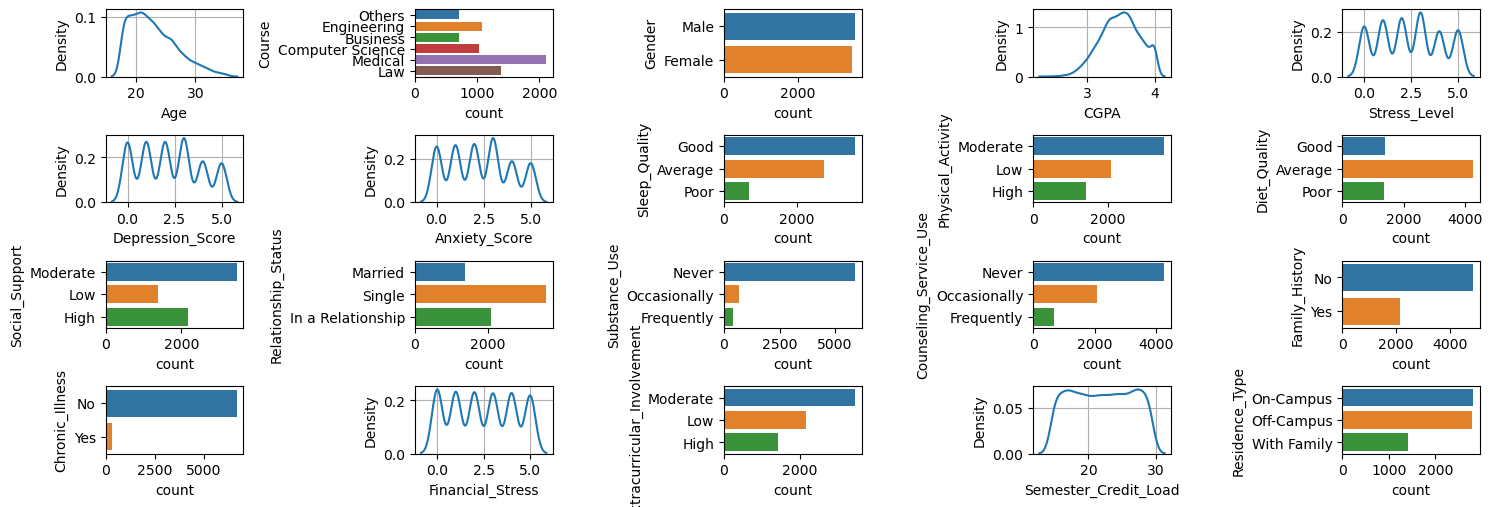

In [6]:
r=5
c=5
it=1
for i,j in enumerate(df.columns):
    plt.subplot(r,c,it)
    if df[j].dtype=='object':
        sns.countplot(y=df[j])
    else:
        sns.kdeplot(df[j])
        plt.grid()
    it+=1
plt.tight_layout()
plt.show()

In [7]:
df.head()

,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type
0,25,Others,Male,3.56,3,3,2,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,2,Moderate,17,On-Campus
1,24,Engineering,Female,2.44,0,3,0,Average,Low,Average,Low,Single,Occasionally,Occasionally,No,No,3,Low,27,On-Campus
2,19,Business,Female,3.74,4,0,3,Good,Low,Average,Moderate,In a Relationship,Never,Occasionally,No,No,4,High,15,On-Campus
3,19,Computer Science,Male,3.65,2,1,0,Average,Low,Average,Moderate,Single,NaN,Never,No,No,4,Moderate,20,Off-Campus
4,18,Business,Male,3.40,3,3,4,Good,Low,Average,High,Married,Never,Never,No,Yes,0,High,23,On-Campus


In [8]:
df.isnull().sum()

Age                             0
Course                          0
Gender                          0
CGPA                           12
Stress_Level                    0
Depression_Score                0
Anxiety_Score                   0
Sleep_Quality                   0
Physical_Activity               0
Diet_Quality                    0
Social_Support                  0
Relationship_Status             0
Substance_Use                  15
Counseling_Service_Use          0
Family_History                  0
Chronic_Illness                 0
Financial_Stress                0
Extracurricular_Involvement     0
Semester_Credit_Load            0
Residence_Type                  0
dtype: int64

In [9]:
df=df.dropna()
df.head()

,Age,Course,Gender,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type
0,25,Others,Male,3.56,3,3,2,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,2,Moderate,17,On-Campus
1,24,Engineering,Female,2.44,0,3,0,Average,Low,Average,Low,Single,Occasionally,Occasionally,No,No,3,Low,27,On-Campus
2,19,Business,Female,3.74,4,0,3,Good,Low,Average,Moderate,In a Relationship,Never,Occasionally,No,No,4,High,15,On-Campus
4,18,Business,Male,3.40,3,3,4,Good,Low,Average,High,Married,Never,Never,No,Yes,0,High,23,On-Campus
5,21,Medical,Female,3.35,2,4,3,Good,Moderate,Good,High,Single,Never,Never,No,No,5,Moderate,19,Off-Campus


In [10]:
df.shape

(6995, 20)

In [11]:
cat = df.select_dtypes(include='object')
cat.head()

,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Extracurricular_Involvement,Residence_Type
0,Others,Male,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,Moderate,On-Campus
1,Engineering,Female,Average,Low,Average,Low,Single,Occasionally,Occasionally,No,No,Low,On-Campus
2,Business,Female,Good,Low,Average,Moderate,In a Relationship,Never,Occasionally,No,No,High,On-Campus
4,Business,Male,Good,Low,Average,High,Married,Never,Never,No,Yes,High,On-Campus
5,Medical,Female,Good,Moderate,Good,High,Single,Never,Never,No,No,Moderate,Off-Campus


In [12]:
for i in ['Family_History','Chronic_Illness']:
    cat[i] = cat[i].replace({'Yes':1,'No':0})

In [13]:
for i in ['Physical_Activity','Social_Support','Extracurricular_Involvement']:
    cat[i] = cat[i].replace({'Low':1,'Moderate':2,'High':3})

In [14]:
for i in ['Sleep_Quality','Diet_Quality']:
    cat[i] = cat[i].replace({'Poor':1,'Average':2,'Good':3})

In [15]:
for i in ['Substance_Use','Counseling_Service_Use']:
    cat[i] = cat[i].replace({'Never':0,'Occasionally':1,'Frequently':2})

In [16]:
cat['Course']=cat['Course'].map(cat['Course'].value_counts(normalize=True))
cat.head()

,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Extracurricular_Involvement,Residence_Type
0,0.102073,Male,3,2,3,2,Married,0,0,0,0,2,On-Campus
1,0.152538,Female,2,1,2,1,Single,1,1,0,0,1,On-Campus
2,0.102216,Female,3,1,2,2,In a Relationship,0,1,0,0,3,On-Campus
4,0.102216,Male,3,1,2,3,Married,0,0,0,1,3,On-Campus
5,0.299643,Female,3,2,3,3,Single,0,0,0,0,2,Off-Campus


In [17]:
cat['Gender'] = cat['Gender'].replace({'Male':1,'Female':0})
cat.head()

,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Extracurricular_Involvement,Residence_Type
0,0.102073,1,3,2,3,2,Married,0,0,0,0,2,On-Campus
1,0.152538,0,2,1,2,1,Single,1,1,0,0,1,On-Campus
2,0.102216,0,3,1,2,2,In a Relationship,0,1,0,0,3,On-Campus
4,0.102216,1,3,1,2,3,Married,0,0,0,1,3,On-Campus
5,0.299643,0,3,2,3,3,Single,0,0,0,0,2,Off-Campus


In [18]:
cat['Relationship_Status'].value_counts(normalize=True)

Single               0.509221
In a Relationship    0.295783
Married              0.194996
Name: Relationship_Status, dtype: float64

In [19]:
cat['Relationship_Status']=cat['Relationship_Status'].map(cat['Relationship_Status'].value_counts(normalize=True))
cat.head()

,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Extracurricular_Involvement,Residence_Type
0,0.102073,1,3,2,3,2,0.194996,0,0,0,0,2,On-Campus
1,0.152538,0,2,1,2,1,0.509221,1,1,0,0,1,On-Campus
2,0.102216,0,3,1,2,2,0.295783,0,1,0,0,3,On-Campus
4,0.102216,1,3,1,2,3,0.194996,0,0,0,1,3,On-Campus
5,0.299643,0,3,2,3,3,0.509221,0,0,0,0,2,Off-Campus


In [20]:
cat['Residence_Type']=cat['Residence_Type'].map(cat['Residence_Type'].value_counts(normalize=True))
cat.head()

,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Extracurricular_Involvement,Residence_Type
0,0.102073,1,3,2,3,2,0.194996,0,0,0,0,2,0.401001
1,0.152538,0,2,1,2,1,0.509221,1,1,0,0,1,0.401001
2,0.102216,0,3,1,2,2,0.295783,0,1,0,0,3,0.401001
4,0.102216,1,3,1,2,3,0.194996,0,0,0,1,3,0.401001
5,0.299643,0,3,2,3,3,0.509221,0,0,0,0,2,0.396569


In [21]:
cat.head()

,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Extracurricular_Involvement,Residence_Type
0,0.102073,1,3,2,3,2,0.194996,0,0,0,0,2,0.401001
1,0.152538,0,2,1,2,1,0.509221,1,1,0,0,1,0.401001
2,0.102216,0,3,1,2,2,0.295783,0,1,0,0,3,0.401001
4,0.102216,1,3,1,2,3,0.194996,0,0,0,1,3,0.401001
5,0.299643,0,3,2,3,3,0.509221,0,0,0,0,2,0.396569


<Axes: >

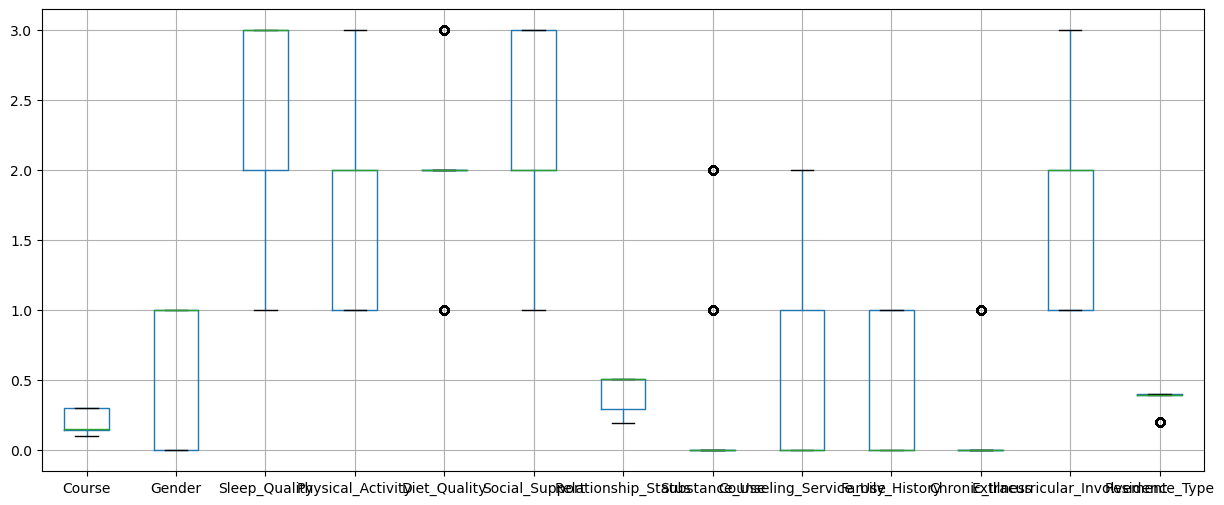

In [22]:
cat.boxplot()

In [23]:
num = df.select_dtypes(include=np.number)
num.head()

,Age,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Financial_Stress,Semester_Credit_Load
0,25,3.56,3,3,2,2,17
1,24,2.44,0,3,0,3,27
2,19,3.74,4,0,3,4,15
4,18,3.40,3,3,4,0,23
5,21,3.35,2,4,3,5,19


In [24]:
from sklearn.preprocessing import MinMaxScaler

In [25]:
mmax = MinMaxScaler()

In [26]:
df=pd.concat([cat,num],axis=1)
df.head()

,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Extracurricular_Involvement,Residence_Type,Age,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Financial_Stress,Semester_Credit_Load
0,0.102073,1,3,2,3,2,0.194996,0,0,0,0,2,0.401001,25,3.56,3,3,2,2,17
1,0.152538,0,2,1,2,1,0.509221,1,1,0,0,1,0.401001,24,2.44,0,3,0,3,27
2,0.102216,0,3,1,2,2,0.295783,0,1,0,0,3,0.401001,19,3.74,4,0,3,4,15
4,0.102216,1,3,1,2,3,0.194996,0,0,0,1,3,0.401001,18,3.40,3,3,4,0,23
5,0.299643,0,3,2,3,3,0.509221,0,0,0,0,2,0.396569,21,3.35,2,4,3,5,19


In [27]:
df.columns

Index(['Course', 'Gender', 'Sleep_Quality', 'Physical_Activity',
       'Diet_Quality', 'Social_Support', 'Relationship_Status',
       'Substance_Use', 'Counseling_Service_Use', 'Family_History',
       'Chronic_Illness', 'Extracurricular_Involvement', 'Residence_Type',
       'Age', 'CGPA', 'Stress_Level', 'Depression_Score', 'Anxiety_Score',
       'Financial_Stress', 'Semester_Credit_Load'],
      dtype='object')

In [28]:
scale=['Sleep_Quality', 'Physical_Activity',
       'Diet_Quality', 'Social_Support','Extracurricular_Involvement','Age', 'CGPA', 'Stress_Level', 'Depression_Score', 'Anxiety_Score',
       'Financial_Stress', 'Semester_Credit_Load']

In [29]:
scale

['Sleep_Quality',
 'Physical_Activity',
 'Diet_Quality',
 'Social_Support',
 'Extracurricular_Involvement',
 'Age',
 'CGPA',
 'Stress_Level',
 'Depression_Score',
 'Anxiety_Score',
 'Financial_Stress',
 'Semester_Credit_Load']

In [30]:
df[scale] = mmax.fit_transform(df[scale])
df.head()

,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Extracurricular_Involvement,Residence_Type,Age,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Financial_Stress,Semester_Credit_Load
0,0.102073,1,1.0,0.5,1.0,0.5,0.194996,0,0,0,0,0.5,0.401001,0.411765,0.717949,0.6,0.6,0.4,0.4,0.142857
1,0.152538,0,0.5,0.0,0.5,0.0,0.509221,1,1,0,0,0.0,0.401001,0.352941,0.000000,0.0,0.6,0.0,0.6,0.857143
2,0.102216,0,1.0,0.0,0.5,0.5,0.295783,0,1,0,0,1.0,0.401001,0.058824,0.833333,0.8,0.0,0.6,0.8,0.000000
4,0.102216,1,1.0,0.0,0.5,1.0,0.194996,0,0,0,1,1.0,0.401001,0.000000,0.615385,0.6,0.6,0.8,0.0,0.571429
5,0.299643,0,1.0,0.5,1.0,1.0,0.509221,0,0,0,0,0.5,0.396569,0.176471,0.583333,0.4,0.8,0.6,1.0,0.285714


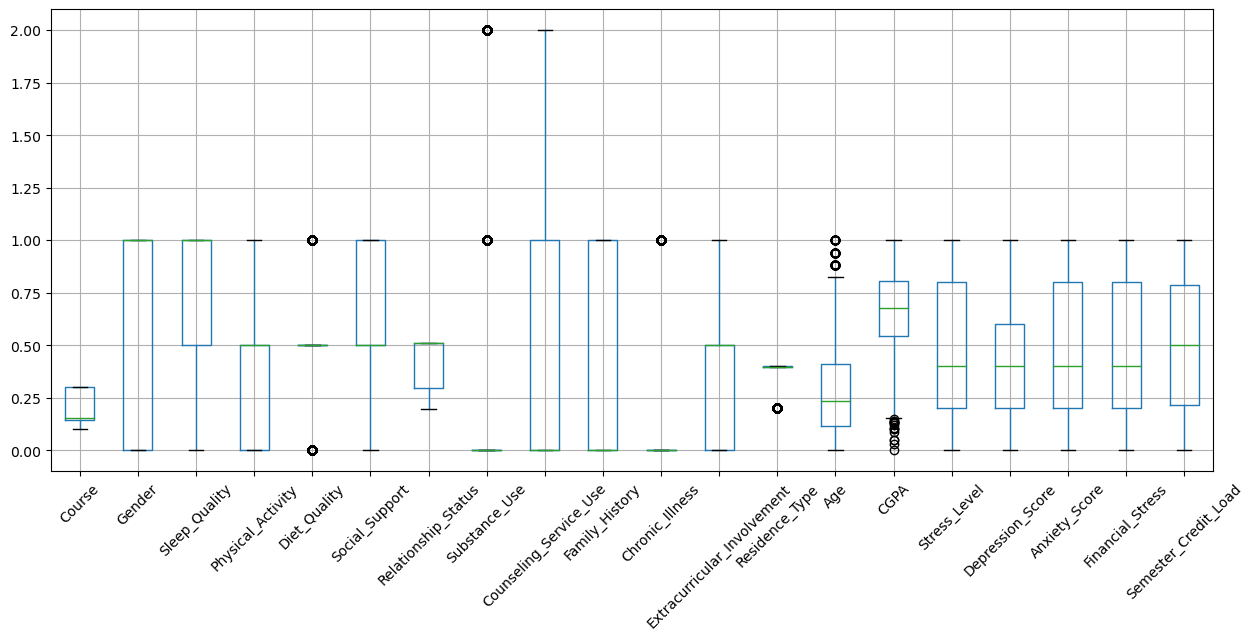

In [31]:
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [32]:
from sklearn.cluster import KMeans


In [33]:
wcss = []
lim=15
for k in range(2,lim):
    kmeans = KMeans(n_clusters=k,random_state=42)
    model = kmeans.fit(df)
    wcss.append(model.inertia_)

In [34]:
wcss

[14633.36560550561,
 13240.06167977945,
 12468.5264558458,
 11745.37945643807,
 11260.539898874315,
 10917.748091407218,
 10631.49068475008,
 10403.587572628569,
 10197.701665974842,
 10005.898481028085,
 9873.195790966063,
 9771.190726848004,
 9658.265310929402]

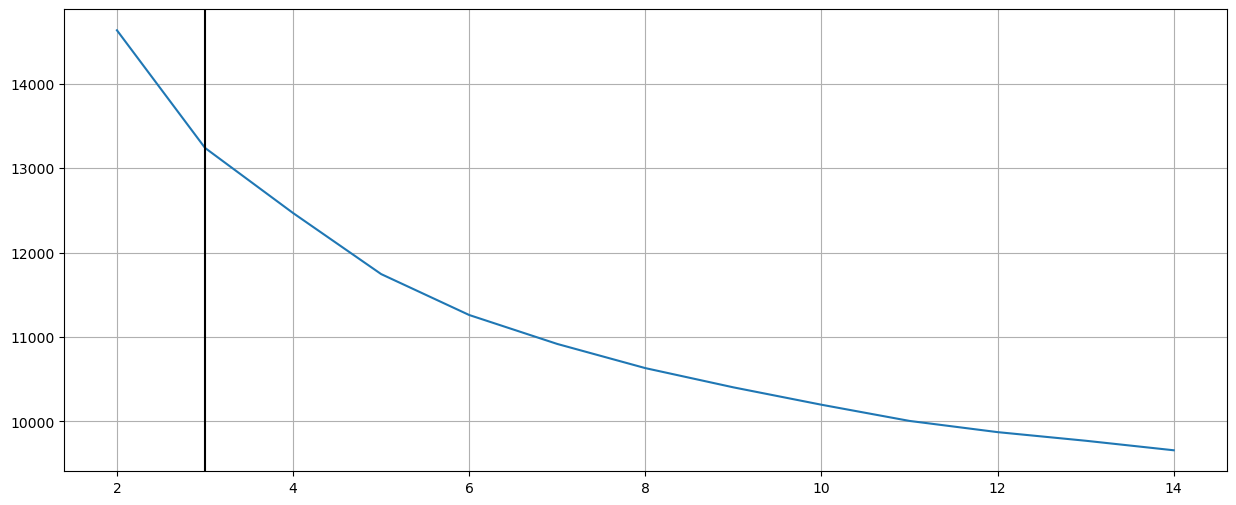

In [35]:
plt.plot(range(2,lim),wcss)
plt.axvline(3,color='k')
plt.grid()
plt.show()

The number of clusters should be 3 as per elbow method

In [36]:
kmeans = KMeans(n_clusters=3,random_state=42)
model = kmeans.fit(df)
model.labels_

array([1, 2, 0, ..., 0, 0, 1], dtype=int32)

In [37]:
df.shape[0]

6995

In [38]:
df['clusters'] = pd.Series(model.labels_)
df.head()

,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,...,Extracurricular_Involvement,Residence_Type,Age,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Financial_Stress,Semester_Credit_Load,clusters
0,0.102073,1,1.0,0.5,1.0,0.5,0.194996,0,0,0,...,0.5,0.401001,0.411765,0.717949,0.6,0.6,0.4,0.4,0.142857,1.0
1,0.152538,0,0.5,0.0,0.5,0.0,0.509221,1,1,0,...,0.0,0.401001,0.352941,0.000000,0.0,0.6,0.0,0.6,0.857143,2.0
2,0.102216,0,1.0,0.0,0.5,0.5,0.295783,0,1,0,...,1.0,0.401001,0.058824,0.833333,0.8,0.0,0.6,0.8,0.000000,0.0
4,0.102216,1,1.0,0.0,0.5,1.0,0.194996,0,0,0,...,1.0,0.401001,0.000000,0.615385,0.6,0.6,0.8,0.0,0.571429,1.0
5,0.299643,0,1.0,0.5,1.0,1.0,0.509221,0,0,0,...,0.5,0.396569,0.176471,0.583333,0.4,0.8,0.6,1.0,0.285714,1.0


In [39]:
df

,Course,Gender,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,...,Extracurricular_Involvement,Residence_Type,Age,CGPA,Stress_Level,Depression_Score,Anxiety_Score,Financial_Stress,Semester_Credit_Load,clusters
0,0.102073,1,1.0,0.5,1.0,0.5,0.194996,0,0,0,...,0.5,0.401001,0.411765,0.717949,0.6,0.6,0.4,0.4,0.142857,1.0
1,0.152538,0,0.5,0.0,0.5,0.0,0.509221,1,1,0,...,0.0,0.401001,0.352941,0.000000,0.0,0.6,0.0,0.6,0.857143,2.0
2,0.102216,0,1.0,0.0,0.5,0.5,0.295783,0,1,0,...,1.0,0.401001,0.058824,0.833333,0.8,0.0,0.6,0.8,0.000000,0.0
4,0.102216,1,1.0,0.0,0.5,1.0,0.194996,0,0,0,...,1.0,0.401001,0.000000,0.615385,0.6,0.6,0.8,0.0,0.571429,1.0
5,0.299643,0,1.0,0.5,1.0,1.0,0.509221,0,0,0,...,0.5,0.396569,0.176471,0.583333,0.4,0.8,0.6,1.0,0.285714,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7016,0.197427,0,0.5,0.0,0.5,0.5,0.295783,0,1,0,...,0.5,0.396569,0.117647,0.570513,0.2,0.2,0.2,0.6,1.000000,NaN
7017,0.197427,0,1.0,0.0,0.0,1.0,0.509221,0,2,1,...,1.0,0.396569,0.117647,0.801282,0.6,0.2,1.0,0.2,0.785714,NaN
7018,0.299643,0,1.0,0.5,0.5,1.0,0.509221,0,1,0,...,0.0,0.396569,0.352941,0.826923,0.6,0.8,0.2,0.6,0.000000,NaN
7019,0.102073,1,1.0,1.0,0.0,0.5,0.194996,0,1,0,...,0.5,0.396569,0.470588,0.775641,0.8,1.0,0.2,0.8,0.142857,NaN


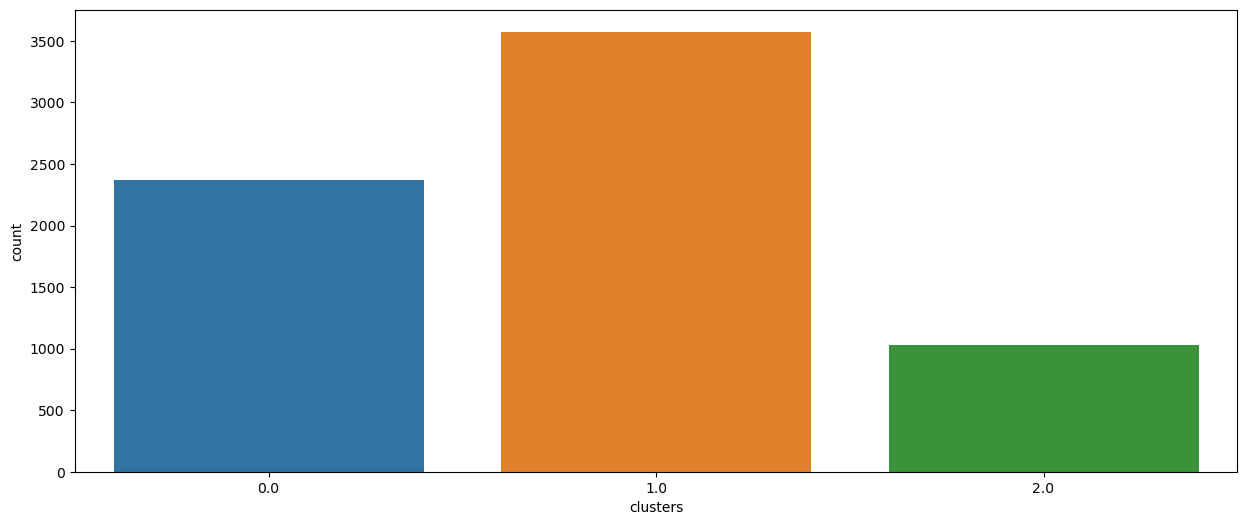

In [40]:
sns.countplot(x=df['clusters'])
plt.show()

In [41]:
sum(df['clusters'].value_counts().values)

6973

In [42]:
from sklearn.metrics import silhouette_score

In [43]:
score = []
lim=15
for k in range(2,lim):
    kmeans = KMeans(n_clusters=k,random_state=42)
    label = kmeans.fit_predict(df.drop('clusters',axis=1))
    scores = silhouette_score(df.drop('clusters',axis=1),label)
    score.append(scores)

In [44]:
score

[0.151467146318334,
 0.1565621199917475,
 0.11509414872453956,
 0.115691807382679,
 0.10214873190043477,
 0.11168209126432777,
 0.12103316219448564,
 0.1257872306692837,
 0.1118981890427277,
 0.10132836933430121,
 0.10454836020562037,
 0.09639066651275471,
 0.08510199373265802]

In [45]:
score_df=pd.DataFrame({'clusters':range(2,lim),'score':score})
score_df[score_df['score']==score_df['score'].max()]

,clusters,score
1,3,0.156562


by using silhouette score method, we get 3 clusters